# E-Commerce Sales Analysis

This project analyzes e-commerce sales data to identify trends and patterns in sales, profit, quantity, categories, regions, and products.

In [1]:
print("E-Commerce Sales Analysis")

E-Commerce Sales Analysis


### 1. Importing Libraries

In [2]:
import pandas as pd

### 2. Loading the Dataset

In [3]:
data = pd.read_csv("ecommerce_sales_data (2).csv")

### 3. Initial Data Exploration

In [4]:
data.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


In [5]:
data.shape

(3500, 7)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB


In [7]:
data.describe()

,Quantity,Sales,Profit
count,3500.000000,3500.000000,3500.000000
mean,4.931714,3047.966000,527.047203
std,2.575895,2440.213237,504.139732
min,1.000000,51.000000,6.970000
25%,3.000000,1049.500000,158.695000
50%,5.000000,2350.500000,361.070000
75%,7.000000,4537.000000,729.125000
max,9.000000,10782.000000,2946.930000


### 4. Data Quality Check

In [8]:
data.isnull().sum()

Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64

In [9]:
data.duplicated().sum()

np.int64(0)

### 5. Date Conversion and Time Range

In [10]:
data['Order Date'] = pd.to_datetime(data['Order Date'])

In [11]:
data['Order Date'].min() , data['Order Date'].max()

(Timestamp('2022-01-01 00:00:00'), Timestamp('2024-12-31 00:00:00'))

### 6. Overall Sales and Profit

In [12]:
data[['Sales','Profit']].sum()

Sales     10667881.00
Profit     1844665.21
dtype: float64

### 7. Category Analysis

In [13]:
data.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Electronics    5326074
Accessories    4247591
Office         1094216
Name: Sales, dtype: int64

In [14]:
data.groupby('Category')['Profit'].sum().sort_values(ascending=False)

Category
Electronics    923185.59
Accessories    736084.74
Office         185394.88
Name: Profit, dtype: float64

In [15]:
category_performance = data.groupby('Category')[['Sales','Profit','Quantity']].sum()
category_performance['Profit Margin (%)'] = (category_performance['Profit']/category_performance['Sales'])*100
category_performance.sort_values('Profit Margin (%)', ascending=False)


,Sales,Profit,Quantity,Profit Margin (%)
Category,,,,
Electronics,5326074,923185.59,8610,17.333323
Accessories,4247591,736084.74,6917,17.329464
Office,1094216,185394.88,1734,16.943170


### 8. Regional Analysis

In [16]:
data.groupby('Region')['Sales'].sum().sort_values(ascending=False)

Region
West     2844450
East     2675110
South    2659548
North    2488773
Name: Sales, dtype: int64

In [17]:
data.groupby('Region')['Profit'].sum().sort_values(ascending=False)

Region
West     495358.73
East     464888.46
South    458103.27
North    426314.75
Name: Profit, dtype: float64

In [18]:
region_performance = data.groupby('Region')[['Sales','Profit','Quantity']].sum()
region_performance['Profit Margin (%)'] = (region_performance['Profit']/region_performance['Sales'])*100
region_performance.sort_values('Profit Margin (%)', ascending=False)

,Sales,Profit,Quantity,Profit Margin (%)
Region,,,,
West,2844450,495358.73,4488,17.414921
East,2675110,464888.46,4306,17.378293
South,2659548,458103.27,4361,17.224854
North,2488773,426314.75,4106,17.129515


### 9. Product Analysis

In [19]:
data.groupby('Product Name')['Sales'].sum().sort_values(ascending=False)

Product Name
Camera        1177381
Monitor       1160048
Printer       1094216
Mouse         1074398
Smartphone    1069681
Smartwatch    1049211
Keyboard      1024507
Tablet        1023928
Laptop        1005873
Headphones     988638
Name: Sales, dtype: int64

In [20]:
data.groupby('Product Name')['Profit'].sum().sort_values(ascending=False)

Product Name
Camera        207630.99
Monitor       202028.17
Mouse         185763.69
Laptop        185756.81
Printer       185394.88
Smartphone    183296.97
Smartwatch    178995.81
Keyboard      175814.68
Headphones    172478.20
Tablet        167505.01
Name: Profit, dtype: float64

In [21]:
data.groupby('Product Name')['Quantity'].sum().sort_values(ascending=False)

Product Name
Monitor       1876
Smartwatch    1807
Camera        1795
Mouse         1753
Printer       1734
Tablet        1733
Keyboard      1684
Laptop        1658
Smartphone    1617
Headphones    1604
Name: Quantity, dtype: int64

In [22]:
data.groupby('Product Name')[['Quantity','Sales','Profit']].sum().sort_values('Profit',ascending=False)

,Quantity,Sales,Profit
Product Name,,,
Camera,1795,1177381,207630.99
Monitor,1876,1160048,202028.17
Mouse,1753,1074398,185763.69
Laptop,1658,1005873,185756.81
Printer,1734,1094216,185394.88
Smartphone,1617,1069681,183296.97
Smartwatch,1807,1049211,178995.81
Keyboard,1684,1024507,175814.68
Headphones,1604,988638,172478.20


In [23]:
product_analysis = data.groupby('Product Name')[['Quantity','Sales','Profit']].sum().sort_values('Profit',ascending=False)

### 10. Monthly Sales and Profit Analysis

In [24]:
data['Year-Month'] = data['Order Date'].dt.to_period('M')
monthly_analysis = data.groupby('Year-Month')[['Sales','Profit']].sum()

### 11. Yearly Sales and Profit Analysis

In [25]:
data['Year'] = data['Order Date'].dt.year
yearly_analysis = data.groupby('Year')[['Sales','Profit']].sum()

### 12. Product Profitability Analysis

In [26]:
product_performance = data.groupby('Product Name')[['Sales','Profit','Quantity']].sum()
product_performance['Profit Margin (%)'] = (product_performance['Profit']/product_performance['Sales'])*100
product_performance.sort_values('Profit Margin (%)', ascending=False)

,Sales,Profit,Quantity,Profit Margin (%)
Product Name,,,,
Laptop,1005873,185756.81,1658,18.467223
Camera,1177381,207630.99,1795,17.634987
Headphones,988638,172478.20,1604,17.446042
Monitor,1160048,202028.17,1876,17.415501
Mouse,1074398,185763.69,1753,17.290026
Keyboard,1024507,175814.68,1684,17.160906
Smartphone,1069681,183296.97,1617,17.135667
Smartwatch,1049211,178995.81,1807,17.060039
Printer,1094216,185394.88,1734,16.943170


### 13. Category and Product Performance

In [27]:
category_group = data.groupby(['Category','Product Name'])[['Sales','Profit','Quantity']].sum()

In [28]:
category_group.sort_values(['Category','Sales'],ascending=[True,False])

Sales     Profit  Quantity
Category    Product Name                              
Accessories Monitor       1160048  202028.17      1876
            Mouse         1074398  185763.69      1753
            Keyboard      1024507  175814.68      1684
            Headphones     988638  172478.20      1604
Electronics Camera        1177381  207630.99      1795
            Smartphone    1069681  183296.97      1617
            Smartwatch    1049211  178995.81      1807
            Tablet        1023928  167505.01      1733
            Laptop        1005873  185756.81      1658
Office      Printer       1094216  185394.88      1734

In [29]:
category_group.sort_values(['Category','Profit'],ascending=[True,False])

Sales     Profit  Quantity
Category    Product Name                              
Accessories Monitor       1160048  202028.17      1876
            Mouse         1074398  185763.69      1753
            Keyboard      1024507  175814.68      1684
            Headphones     988638  172478.20      1604
Electronics Camera        1177381  207630.99      1795
            Laptop        1005873  185756.81      1658
            Smartphone    1069681  183296.97      1617
            Smartwatch    1049211  178995.81      1807
            Tablet        1023928  167505.01      1733
Office      Printer       1094216  185394.88      1734

In [30]:
category_group.sort_values(['Category', 'Quantity'], ascending=[True, False])

Sales     Profit  Quantity
Category    Product Name                              
Accessories Monitor       1160048  202028.17      1876
            Mouse         1074398  185763.69      1753
            Keyboard      1024507  175814.68      1684
            Headphones     988638  172478.20      1604
Electronics Smartwatch    1049211  178995.81      1807
            Camera        1177381  207630.99      1795
            Tablet        1023928  167505.01      1733
            Laptop        1005873  185756.81      1658
            Smartphone    1069681  183296.97      1617
Office      Printer       1094216  185394.88      1734

### 14. Regional and Category Performance

In [31]:
region_category = data.groupby(['Region','Category'])[['Sales','Profit','Quantity']].sum()

In [32]:
region_category.sort_values(['Region', 'Sales'], ascending=[True, False])

Sales     Profit  Quantity
Region Category                                 
East   Electronics  1377211  239660.41      2255
       Accessories  1032315  177839.91      1672
       Office        265584   47388.14       379
North  Electronics  1244702  221585.99      2026
       Accessories  1020641  172153.41      1704
       Office        223430   32575.35       376
South  Electronics  1245527  214733.11      2039
       Accessories  1076668  187123.37      1822
       Office        337353   56246.79       500
West   Electronics  1458634  247206.08      2290
       Accessories  1117967  198968.05      1719
       Office        267849   49184.60       479

In [33]:
region_category.sort_values(['Region', 'Profit'], ascending=[True, False])

Sales     Profit  Quantity
Region Category                                 
East   Electronics  1377211  239660.41      2255
       Accessories  1032315  177839.91      1672
       Office        265584   47388.14       379
North  Electronics  1244702  221585.99      2026
       Accessories  1020641  172153.41      1704
       Office        223430   32575.35       376
South  Electronics  1245527  214733.11      2039
       Accessories  1076668  187123.37      1822
       Office        337353   56246.79       500
West   Electronics  1458634  247206.08      2290
       Accessories  1117967  198968.05      1719
       Office        267849   49184.60       479

### 15. Yearly and Category Performance

In [34]:
year_category = data.groupby(['Year', 'Category'])[['Sales', 'Profit', 'Quantity']].sum()

In [35]:
year_category.sort_values(['Year', 'Sales'], ascending=[True, False])

Sales     Profit  Quantity
Year Category                                 
2022 Electronics  1616149  286236.30      2715
     Accessories  1329731  238187.58      2183
     Office        310090   48433.10       489
2023 Electronics  1881367  331270.15      2919
     Accessories  1495723  261626.94      2333
     Office        409502   73969.33       673
2024 Electronics  1828558  305679.14      2976
     Accessories  1422137  236270.22      2401
     Office        374624   62992.45       572

In [36]:
year_category.sort_values(['Year', 'Profit'], ascending=[True, False])

Sales     Profit  Quantity
Year Category                                 
2022 Electronics  1616149  286236.30      2715
     Accessories  1329731  238187.58      2183
     Office        310090   48433.10       489
2023 Electronics  1881367  331270.15      2919
     Accessories  1495723  261626.94      2333
     Office        409502   73969.33       673
2024 Electronics  1828558  305679.14      2976
     Accessories  1422137  236270.22      2401
     Office        374624   62992.45       572

### 16. Data Visualization

In [37]:
import matplotlib.pyplot as plt

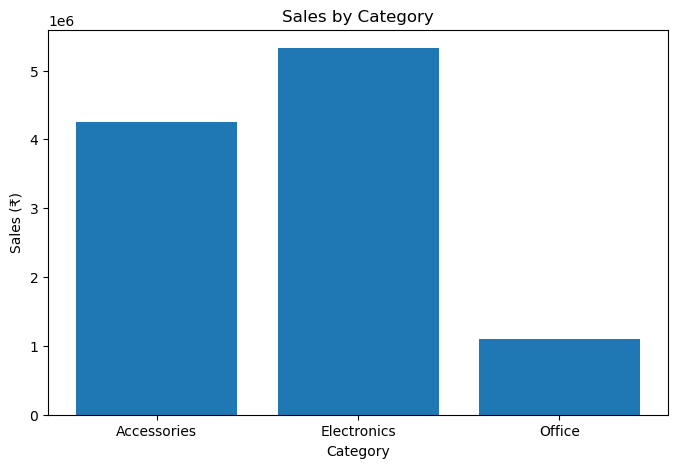

In [38]:
plt.figure(figsize=(8,5))
plt.bar(category_performance.index, category_performance['Sales'])

plt.xlabel('Category')
plt.ylabel('Sales (₹)')
plt.title('Sales by Category')

plt.show()

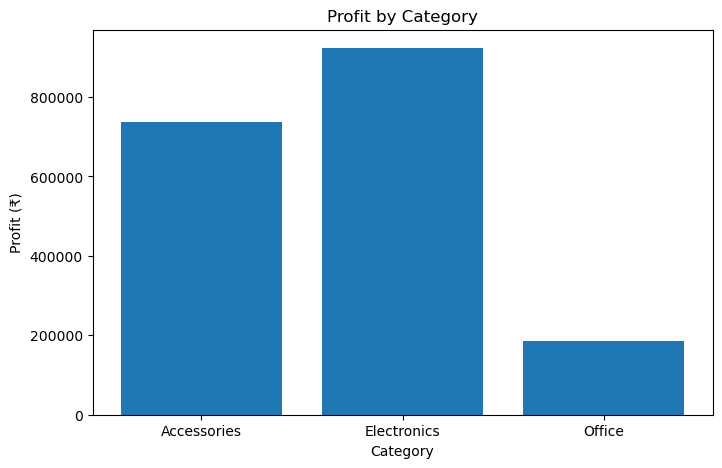

In [39]:
plt.figure(figsize=(8,5))
plt.bar(category_performance.index, category_performance['Profit'])

plt.xlabel('Category')
plt.ylabel('Profit (₹)')
plt.title('Profit by Category')

plt.show()

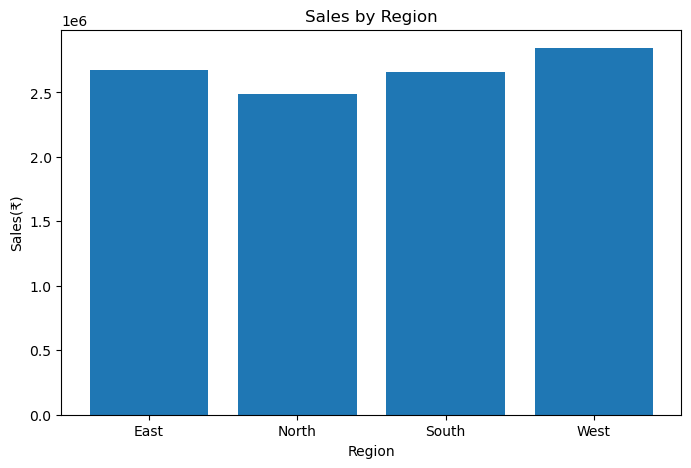

In [40]:
plt.figure(figsize=(8,5))
plt.bar(region_performance.index, region_performance['Sales'])

plt.xlabel('Region')
plt.ylabel('Sales(₹)')
plt.title('Sales by Region')

plt.show()

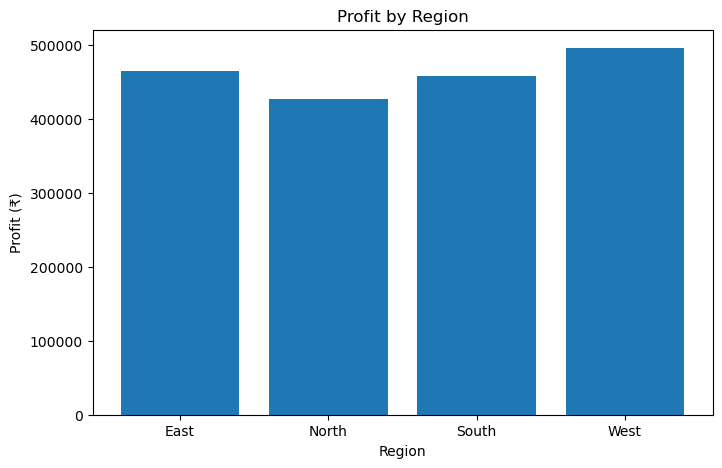

In [41]:
plt.figure(figsize=(8,5))
plt.bar(region_performance.index, region_performance['Profit'])

plt.xlabel('Region')
plt.ylabel('Profit (₹)')
plt.title('Profit by Region')

plt.show()

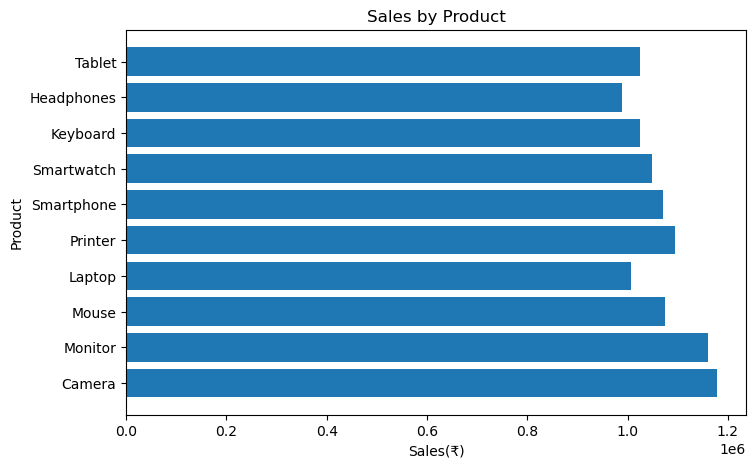

In [42]:
plt.figure(figsize=(8,5))
plt.barh(product_analysis.index,product_analysis['Sales'])

plt.ylabel('Product')
plt.xlabel('Sales(₹)')
plt.title('Sales by Product')


plt.show()

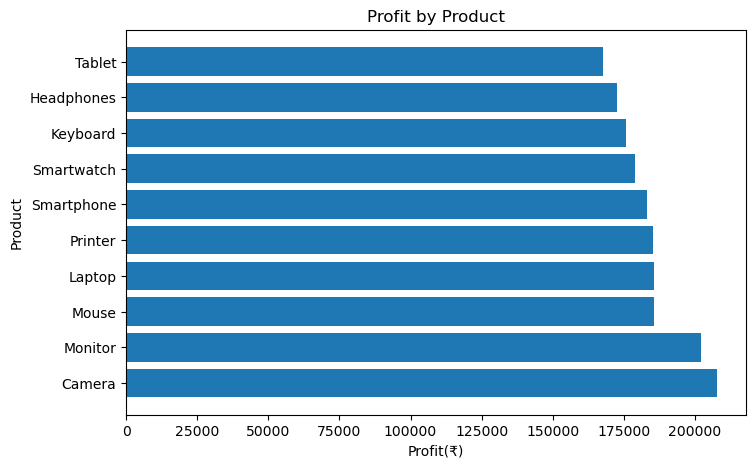

In [43]:
plt.figure(figsize=(8,5))
plt.barh(product_analysis.index,product_analysis['Profit'])

plt.ylabel('Product')
plt.xlabel('Profit(₹)')
plt.title('Profit by Product')


plt.show()

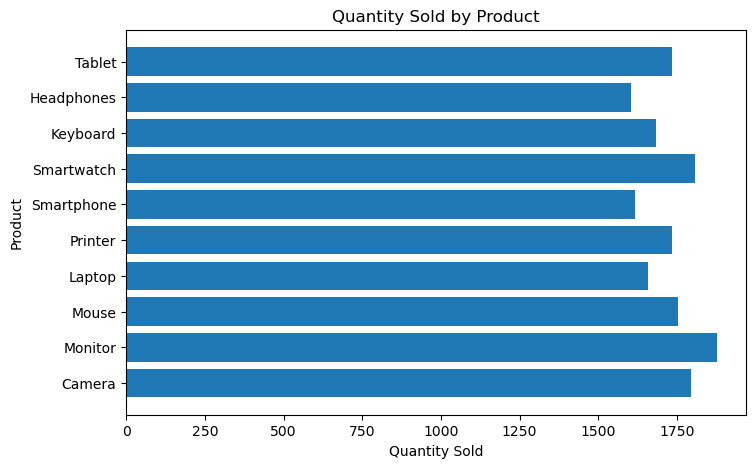

In [44]:
plt.figure(figsize=(8,5))
plt.barh(product_analysis.index,product_analysis['Quantity'])

plt.ylabel('Product')
plt.xlabel('Quantity Sold')
plt.title('Quantity Sold by Product')


plt.show()

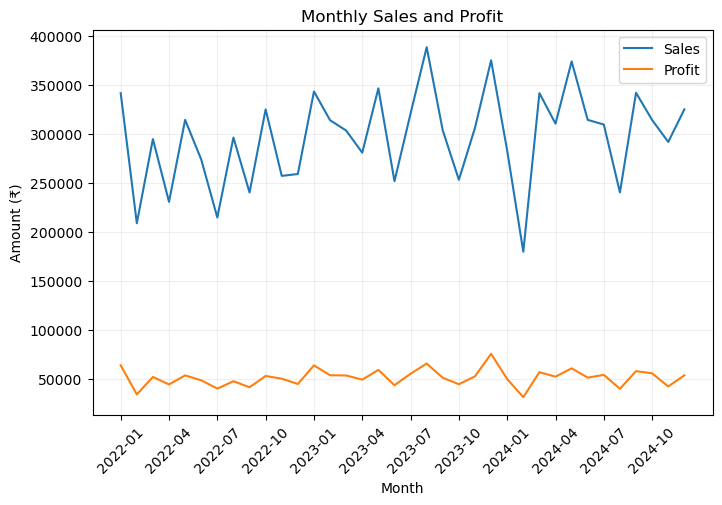

In [45]:
plt.figure(figsize=(8,5))
plt.plot(monthly_analysis.index.astype(str),monthly_analysis['Sales'],label='Sales')
plt.plot(monthly_analysis.index.astype(str),monthly_analysis['Profit'],label='Profit')
plt.grid(alpha=0.2)
plt.xlabel('Month')
plt.ylabel('Amount (₹)')
plt.title('Monthly Sales and Profit')
plt.xticks(range(0, len(monthly_analysis), 3),monthly_analysis.index.astype(str)[::3],rotation=45)
plt.legend()
plt.show()

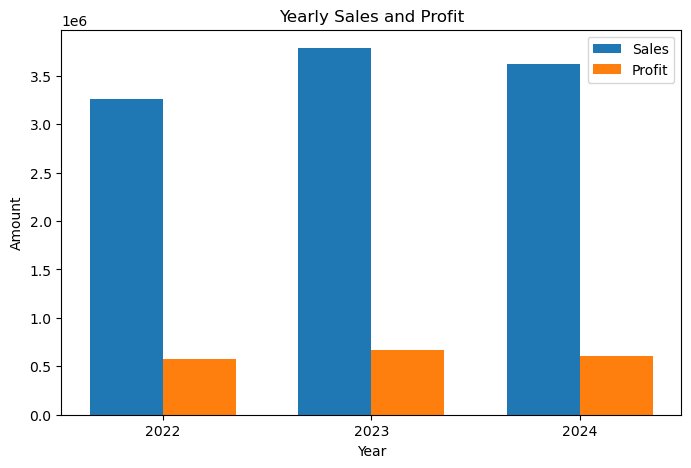

In [46]:
plt.figure(figsize=(8,5))
width = 0.35
plt.bar(yearly_analysis.index,yearly_analysis['Sales'],width=width, label='Sales')
plt.bar((yearly_analysis.index)+width,yearly_analysis['Profit'],width=width, label='Profit')

plt.xlabel('Year')
plt.ylabel('Amount')
plt.title('Yearly Sales and Profit')
plt.xticks(yearly_analysis.index+width/2,yearly_analysis.index)
plt.legend()
plt.show()

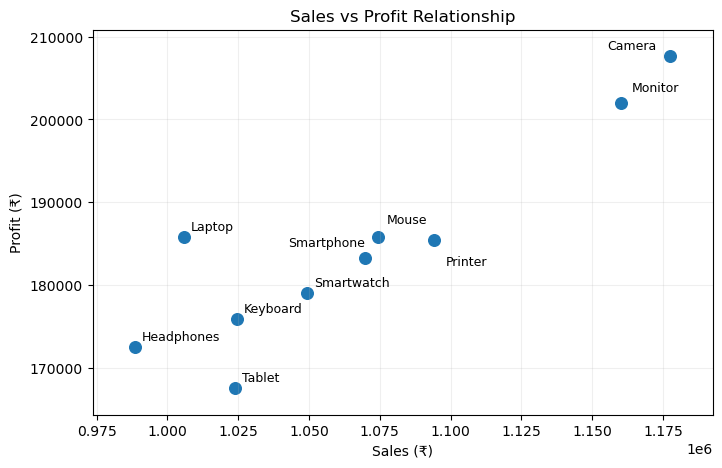

In [47]:
plt.figure(figsize=(8,5))
plt.scatter(product_analysis['Sales'],product_analysis['Profit'],s=70)
plt.xlabel('Sales (₹)')
plt.ylabel('Profit (₹)')
plt.title('Sales vs Profit Relationship')
offsets = {
    'Camera': (-45, 5),
    'Monitor': (8, 8),
    'Mouse': (6, 10),
    'Smartphone': (-55, 8),
    'Printer': (8, -18)
}
for product_name,row in product_analysis.iterrows():
    Sales = row['Sales']
    Profit = row['Profit']
    
    plt.annotate(product_name,(Sales,Profit),xytext=offsets.get(product_name, (5,5)),textcoords='offset points',fontsize=9)
plt.margins(x=0.08, y=0.08)
plt.grid(alpha=0.2)
plt.show()

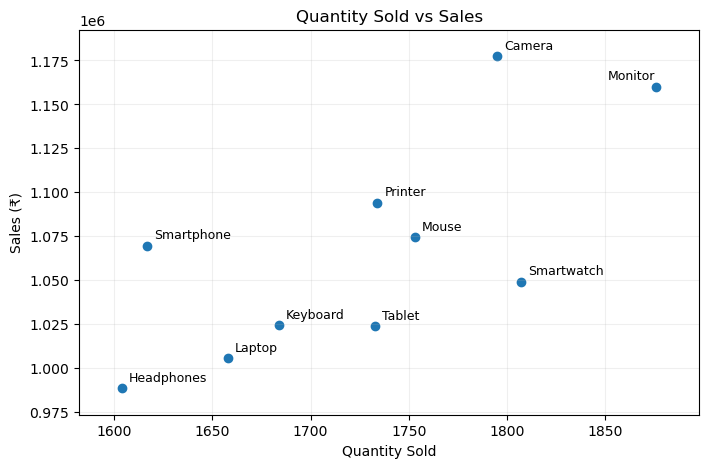

In [48]:
plt.figure(figsize=(8,5))
plt.scatter(product_analysis['Quantity'],product_analysis['Sales'])
plt.xlabel('Quantity Sold')
plt.ylabel('Sales (₹)')
plt.title('Quantity Sold vs Sales')
offsets = {'Monitor': (-35, 5),}
for product_name,row in product_analysis.iterrows():
    Quantity = row['Quantity']
    Sales = row['Sales']
    plt.annotate(product_name,(Quantity,Sales),xytext=offsets.get(product_name, (5,5)),textcoords='offset points',fontsize=9)
plt.margins(x=0.08, y=0.08)
plt.grid(alpha=0.2)
plt.show()

### 17. Key Business Insights

#### 1. Product Performance
Camera is the strongest-performing product, generating the highest sales and profit, while Monitor has the highest quantity sold. Tablet records the lowest profit among the products analyzed.

#### 2. Category Performance
Electronics is the strongest-performing category, generating the highest sales, profit, and quantity sold. In contrast, Office has the lowest profit among the categories analyzed.

#### 3. Regional Performance 
West is the strongest-performing region, recording the highest sales, profit, and quantity sold. In contrast, North has the lowest profit among the regions analyzed.

#### 4. Yearly Performance
2023 was the strongest-performing year, recording the highest sales and profit, while 2022 recorded the lowest sales and profit among the years analyzed.

#### 5. Monthly Performance
August 2023 recorded the highest monthly sales, while February 2024 recorded the lowest sales and lowest profit. December 2023 achieved the highest monthly profit, indicating particularly strong profitability during that month.

#### 6. Product Profit Analysis
Laptop has the highest profit margin at 18.47%, while Tablet has the lowest at 16.36%. Although Camera generates the highest total profit, Laptop is more profitable relative to its sales.

#### 7. Category and Product Performance Analysis
Within Accessories and Office, the same products lead sales, profit, and quantity. However, Electronics shows a different pattern: Camera generates the highest sales and profit, while Smartwatch has the highest quantity sold. This suggests that unit volume alone does not determine revenue or profitability.

#### 8. Regional and Category Performance Analysis
1. Electronics is the strongest-performing category across all four regions, generating the highest sales, profit, and quantity sold in East, North, South, and West. This shows that its strong performance is consistent across regions rather than being driven by a single market.

2. Office consistently records substantially lower sales, profit, and quantity than Electronics and Accessories across all four regions, indicating weaker performance across geographic markets.

#### 9. Yearly and Category Performance Analysis
Electronics remained the strongest-performing category across all three years, leading in sales, profit, and quantity. Its sales and profit increased significantly in 2023 before declining slightly in 2024, while quantity continued to grow each year. Office remained the weakest-performing category throughout the period, despite showing growth in 2023.

### 18. Overall Business Performance

In [49]:
total_sales = data['Sales'].sum()
print(total_sales)

10667881


In [50]:
total_profit = data['Profit'].sum()
print(total_profit)

1844665.21


In [51]:
total_quantity = data['Quantity'].sum()
print(total_quantity)

17261


In [52]:
overall_profit_margin = (total_profit/total_sales)*100
print(overall_profit_margin)

17.29176778406133


#### Overall Performance Summary

| Metric | Value |
|---|---:|
| Total Sales | 10,667,881 |
| Total Profit | 1,844,665.21 |
| Total Quantity Sold | 17,261 |
| Overall Profit Margin | 17.29% |


The business generated total sales of 10.67M and profit of 1.84M from 17,261 units sold, resulting in an overall profit margin of 17.29%.

### 19. Final Conclusions

- The business generated total sales of **10.67M** and total profit of **1.84M** from **17,261 units sold**, resulting in an overall profit margin of **17.29%**.

- **Camera** was the strongest-performing product in terms of sales and total profit, while **Laptop** achieved the highest profit margin.

- **Electronics** consistently remained the strongest-performing category across products, regions, and years, while **Office** showed comparatively weaker performance.

- **West** was the strongest-performing region, and **2023** was the strongest year in terms of sales and profit.

- Higher quantity sold did not always translate into higher sales or profitability, highlighting the importance of considering both sales volume and profit margins when evaluating product performance.

### 20. Business Recommendations
- **Focus on Electronics:** Electronics consistently leads in sales, profit, and quantity across regions and years, making it the strongest category for continued business focus.

- **Investigate Office category performance:** Office consistently records lower sales, profit, and quantity across regions and years. Its weaker performance should be investigated to identify opportunities for improvement.

- **Prioritize profitable products:** Camera generates the highest total sales and profit, while Laptop has the highest profit margin. Product decisions should therefore consider both revenue contribution and profitability.

- **Monitor sales efficiency:** Higher quantities sold do not always result in higher sales or profit. Monitoring profit margins alongside sales volume can help identify products that generate stronger returns.

- **Investigate the 2024 slowdown:** Sales and profit declined in 2024 compared with 2023, despite quantity sold increasing for Electronics. This warrants further investigation into pricing, product mix, or other factors affecting revenue and profitability.

- **Review seasonal performance:** February 2024 recorded the lowest monthly sales and profit, suggesting a period that may require further investigation for potential seasonal or operational factors.